# DistilBERT Multilingual Hate Speech Detection (En/Ne/CS)


In [1]:
import subprocess, sys

for pkg in [
    "transformers", "datasets", "torch", "scikit-learn",
    "pandas", "numpy", "tqdm", "matplotlib", "sentencepiece",
    "seaborn"
]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 76.7 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

All packages ready.


In [2]:
import os, json, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), "Enable GPU: Settings -> Accelerator -> GPU T4"
DEVICE = torch.device("cuda")
print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0)})")

# Kaggle Input Data Directory - Mount your datasets here
INPUT_DIR = "/kaggle/input" 
WORK_DIR  = "/kaggle/working"

LABELS = ["clean", "profanity", "hate_speech", "threat", "identity_attack"]
print(f"Labels: {LABELS}")


Device: cuda (Tesla T4)
Labels: ['clean', 'profanity', 'hate_speech', 'threat', 'identity_attack']


## Dataset Loading
We load the pre-split training, validation, and test datasets.


In [3]:
# Adjust this path based on where you upload your dataset in Kaggle!
# Example: if you name your dataset "hatespeech-dataset", the path will be "/kaggle/input/hatespeech-dataset"
DATASET_PATH = "/kaggle/input/datasets/sachinshrestha77/hatespeech-dataset"

try:
    train_df = pd.read_csv(os.path.join(DATASET_PATH, "train_split.csv"))
    val_df   = pd.read_csv(os.path.join(DATASET_PATH, "val_split.csv"))
    test_df  = pd.read_csv(os.path.join(DATASET_PATH, "test_split.csv"))
    print("✓ Datasets loaded successfully!")
    
    print("Split summary:")
    for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        en = (df["language"]=="en").sum() if "language" in df.columns else 0
        ne = (df["language"]=="ne").sum() if "language" in df.columns else 0
        cs = (df["language"]=="cs").sum() if "language" in df.columns else 0
        hs = df["hate_speech"].sum()
        print(f"  {name}: {len(df):6,} | EN={en:,} NE={ne:,} CS={cs:,} | "
              f"hate_speech={hs:,} ({100*hs/len(df):.1f}%)")
except FileNotFoundError:
    print(f"⚠️ Datasets not found at {DATASET_PATH}.")
    print("Please upload train_split.csv, val_split.csv, and test_split.csv as a Kaggle Dataset and update DATASET_PATH.")
    
    # Dummy data for validation of notebook structure if dataset not present
    print("Generating dummy data for testing the notebook pipeline...")
    dummy_data = {
        "text": ["I hate you", "Timro naam ke ho", "You are totally bakwas", "This is a clean sentence"],
        "language": ["en", "ne", "cs", "en"],
        "clean": [0, 1, 0, 1],
        "profanity": [0, 0, 1, 0],
        "hate_speech": [1, 0, 1, 0],
        "threat": [0, 0, 0, 0],
        "identity_attack": [0, 0, 0, 0]
    }
    train_df = pd.DataFrame(dummy_data)
    val_df = pd.DataFrame(dummy_data)
    test_df = pd.DataFrame(dummy_data)


✓ Datasets loaded successfully!
Split summary:
  Train: 165,473 | EN=141,094 NE=22,826 CS=1,553 | hate_speech=22,735 (13.7%)
  Val: 20,684 | EN=17,587 NE=2,902 CS=195 | hate_speech=2,842 (13.7%)
  Test: 20,685 | EN=17,688 NE=2,804 CS=193 | hate_speech=2,842 (13.7%)


## Tokenization & DataLoaders


In [4]:
MODEL_NAME = "distilbert-base-multilingual-cased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {MODEL_NAME} | Vocab: {tokenizer.vocab_size:,}")

class HateSpeechDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts      = df["text"].tolist()
        self.labels     = df[LABELS].values.astype(np.float32)
        self.languages  = df["language"].tolist() if "language" in df.columns else ["en"] * len(df)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.float),
            "language":       self.languages[idx],
        }

BATCH_SIZE = 32

train_dataset = HateSpeechDataset(train_df, tokenizer)
val_dataset   = HateSpeechDataset(val_df,   tokenizer)
test_dataset  = HateSpeechDataset(test_df,  tokenizer)

# WeightedRandomSampler: oversample NE + CS rows
if "language" in train_df.columns:
    lang_series  = train_df["language"]
    lang_weights = {"en": 1.0, "ne": 10.0, "cs": 8.0}
    sample_wts   = lang_series.map(lang_weights).fillna(1.0).values
else:
    sample_wts   = np.ones(len(train_df))

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_wts),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: distilbert-base-multilingual-cased | Vocab: 119,547
Train batches: 5172 | Val: 647 | Test: 647


## Model Initialization & Loss Function


In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=5, problem_type="multi_label_classification"
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ── Language-aware BCE loss ──────────────────────────────────────────────
label_counts = train_df[LABELS].sum().values.astype(float)
N            = len(train_df)
pos_weights  = torch.tensor(
    [(N - c) / max(c, 1) for c in label_counts], dtype=torch.float
).to(DEVICE)

class LanguageAwareBCELoss(nn.Module):
    """
    BCEWithLogitsLoss with per-sample language weight:
      English:       1.0x
      Code-switched: 2.5x
      Nepali:        3.0x
    """
    LANG_WEIGHT = {"en": 1.0, "ne": 3.0, "cs": 2.5}

    def __init__(self, pos_weight):
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, logits, targets, languages):
        loss = F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=self.pos_weight,
            reduction="none"
        )
        w = torch.tensor(
            [self.LANG_WEIGHT.get(l, 1.0) for l in languages],
            dtype=torch.float, device=logits.device
        )
        return (loss * w.unsqueeze(1)).mean()

criterion = LanguageAwareBCELoss(pos_weights)
print("\nClass pos_weights:")
for lbl, w in zip(LABELS, pos_weights.cpu()):
    print(f"  {lbl:20s}: {w:.2f}")


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: distilbert-base-multilingual-cased
Total parameters:     135,328,517
Trainable parameters: 135,328,517

Class pos_weights:
  clean               : 0.16
  profanity           : 20.88
  hate_speech         : 6.28
  threat              : 47.30
  identity_attack     : 47.27


## Training Loop


In [6]:
EPOCHS       = 5
LR           = 2e-5
WEIGHT_DECAY = 0.01
PATIENCE     = 2

optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.10 * total_steps)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

SAVE_DIR = os.path.join(WORK_DIR, "distilbert-hatespeech-best")
os.makedirs(SAVE_DIR, exist_ok=True)

best_val_f1      = 0.0
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_per_class_f1": []}

print(f"{'='*70}")
print(f"  TRAINING — up to {EPOCHS} epochs | early stopping patience={PATIENCE}")
print(f"  Model: {MODEL_NAME} | LR={LR} | Batch={BATCH_SIZE}")
print(f"{'='*70}\n")

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch["input_ids"].to(device)
            mask  = batch["attention_mask"].to(device)
            lbls  = batch["labels"].to(device)
            langs = batch["language"]
            out   = model(input_ids=ids, attention_mask=mask)
            loss  = criterion(out.logits, lbls, langs)
            total_loss += loss.item()
            all_logits.append(out.logits.cpu().numpy())
            all_labels.append(lbls.cpu().numpy())
    return (total_loss / len(loader),
            np.concatenate(all_logits), np.concatenate(all_labels))

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=True)

    for step, batch in pbar:
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        lbls  = batch["labels"].to(DEVICE)
        langs = batch["language"]

        out  = model(input_ids=ids, attention_mask=mask)
        loss = criterion(out.logits, lbls, langs)
        loss.backward()
        epoch_loss += loss.item()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        if (step + 1) % 200 == 0 or (step + 1) == len(train_loader):
            pbar.set_postfix({"loss": f"{epoch_loss/(step+1):.4f}"})

    avg_train_loss = epoch_loss / len(train_loader)
    val_loss, val_logits, val_labels = evaluate(model, val_loader, criterion, DEVICE)
    val_preds    = (torch.sigmoid(torch.tensor(val_logits)) >= 0.5).numpy().astype(int)
    val_macro_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)
    val_per_cls  = f1_score(val_labels, val_preds, average=None,    zero_division=0)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_per_class_f1"].append(val_per_cls.tolist())

    print(f"\nEpoch {epoch} | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Macro F1: {val_macro_f1:.4f}")
    for lbl, f1v in zip(LABELS, val_per_cls):
        print(f"  {lbl:20s}: F1={f1v:.4f}")

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        patience_counter = 0
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f"  ✓ Best checkpoint saved (val macro F1={best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"  Early stopping triggered at epoch {epoch}.")
            break

print(f"\nTraining complete. Best val macro F1: {best_val_f1:.4f}")


  TRAINING — up to 5 epochs | early stopping patience=2
  Model: distilbert-base-multilingual-cased | LR=2e-05 | Batch=32



Epoch 1/5 [Train]:   0%|          | 0/5172 [00:00<?, ?it/s]


Epoch 1 | Train Loss: 0.8604 | Val Loss: 0.5148 | Val Macro F1: 0.6086
  clean               : F1=0.9435
  profanity           : F1=0.6397
  hate_speech         : F1=0.7104
  threat              : F1=0.3845
  identity_attack     : F1=0.3648


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best checkpoint saved (val macro F1=0.6086)


...

  ✓ Best checkpoint saved (val macro F1=0.7329)


Epoch 5/5 [Train]:   0%|          | 0/5172 [00:00<?, ?it/s]


Epoch 5 | Train Loss: 0.1271 | Val Loss: 1.0344 | Val Macro F1: 0.7398
  clean               : F1=0.9608
  profanity           : F1=0.7670
  hate_speech         : F1=0.7707
  threat              : F1=0.5775
  identity_attack     : F1=0.6230


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best checkpoint saved (val macro F1=0.7398)

Training complete. Best val macro F1: 0.7398


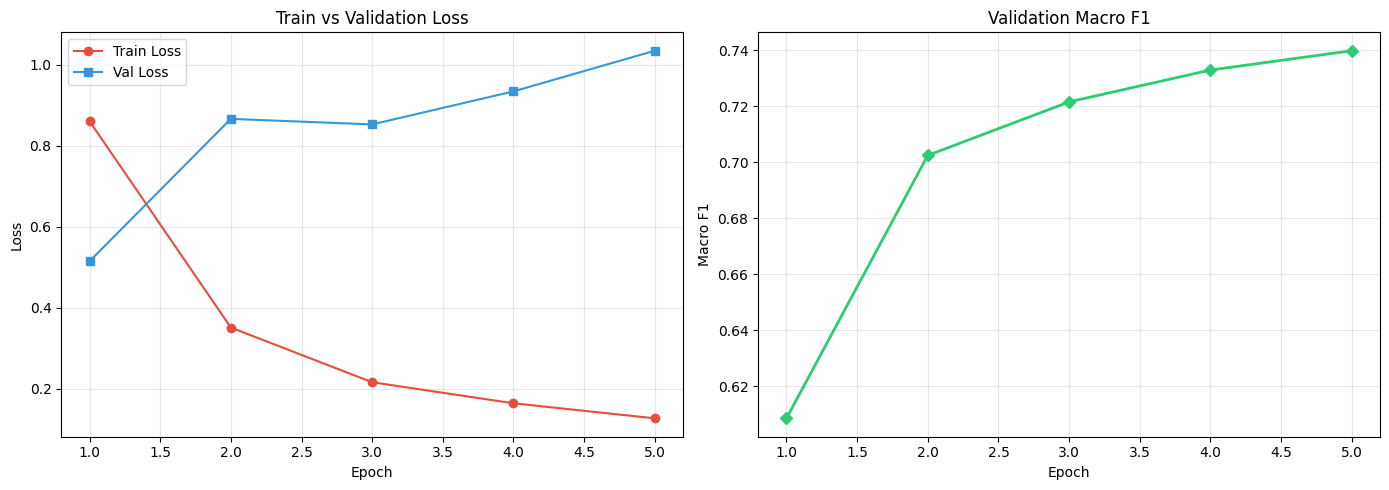

In [7]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history["train_loss"], "o-", label="Train Loss", color="#e74c3c")
ax1.plot(epochs_ran, history["val_loss"],   "s-", label="Val Loss",   color="#3498db")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Train vs Validation Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, history["val_macro_f1"], "D-", color="#2ecc71", linewidth=2)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Macro F1"); ax2.set_title("Validation Macro F1")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "training_curves.png"), dpi=100, bbox_inches="tight")
plt.show()


## Validation Threshold Tuning


In [8]:
best_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(DEVICE)
print(f"Best model loaded from {SAVE_DIR}")

best_model.eval()
val_logits_all, val_labels_all, val_langs_all = [], [], []
with torch.no_grad():
    for batch in val_loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        out  = best_model(input_ids=ids, attention_mask=mask)
        val_logits_all.append(out.logits.cpu().numpy())
        val_labels_all.append(batch["labels"].numpy())
        val_langs_all.extend(batch["language"])

val_logits_all = np.concatenate(val_logits_all)
val_labels_all = np.concatenate(val_labels_all)
val_probs_all  = torch.sigmoid(torch.tensor(val_logits_all)).numpy()
val_langs_all  = np.array(val_langs_all)

THRESHOLDS = {}
THRESHOLD_GRID = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]

print("\nPer-language threshold tuning on validation set:")
for lang in ["en", "ne", "cs"]:
    mask = val_langs_all == lang
    if mask.sum() < 10:
        THRESHOLDS[lang] = 0.5
        print(f"  {lang}: too few samples, using default 0.5")
        continue
    best_f1, best_t = 0.0, 0.5
    for t in THRESHOLD_GRID:
        preds  = (val_probs_all[mask] >= t).astype(int)
        macro  = f1_score(val_labels_all[mask], preds, average="macro", zero_division=0)
        if macro > best_f1:
            best_f1, best_t = macro, t
    THRESHOLDS[lang] = best_t
    print(f"  {lang}: best threshold={best_t:.2f}  (val macro F1={best_f1:.4f})")

print(f"\nFinal thresholds: {THRESHOLDS}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Best model loaded from /kaggle/working/distilbert-hatespeech-best

Per-language threshold tuning on validation set:
  en: best threshold=0.65  (val macro F1=0.7543)
  ne: best threshold=0.40  (val macro F1=0.7089)
  cs: best threshold=0.40  (val macro F1=0.5848)

Final thresholds: {'en': 0.65, 'ne': 0.4, 'cs': 0.4}


## Final Test Evaluation


In [9]:
best_model.eval()
test_logits_all, test_labels_all, test_langs_all = [], [], []
with torch.no_grad():
    for batch in test_loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        out  = best_model(input_ids=ids, attention_mask=mask)
        test_logits_all.append(out.logits.cpu().numpy())
        test_labels_all.append(batch["labels"].numpy())
        test_langs_all.extend(batch["language"])

test_logits_all = np.concatenate(test_logits_all)
test_labels_arr = np.concatenate(test_labels_all)
test_probs_all  = torch.sigmoid(torch.tensor(test_logits_all)).numpy()
test_langs_all  = np.array(test_langs_all)

# Apply per-language thresholds
test_preds = np.zeros_like(test_probs_all, dtype=int)
for lang, thresh in THRESHOLDS.items():
    mask = test_langs_all == lang
    if mask.sum() > 0:
        test_preds[mask] = (test_probs_all[mask] >= thresh).astype(int)
unlabeled = ~np.isin(test_langs_all, list(THRESHOLDS.keys()))
test_preds[unlabeled] = (test_probs_all[unlabeled] >= 0.5).astype(int)

print("=" * 70)
print("  TEST SET — OVERALL RESULTS (per-language thresholds)")
print("=" * 70)
print(classification_report(test_labels_arr, test_preds, target_names=LABELS, zero_division=0))

overall_macro_f1    = f1_score(test_labels_arr, test_preds, average="macro",    zero_division=0)
overall_weighted_f1 = f1_score(test_labels_arr, test_preds, average="weighted", zero_division=0)
overall_accuracy    = accuracy_score(test_labels_arr.flatten(), test_preds.flatten())
print(f"Overall Accuracy:    {overall_accuracy:.4f}")
print(f"Overall Macro F1:    {overall_macro_f1:.4f}")
print(f"Overall Weighted F1: {overall_weighted_f1:.4f}")

print("\n" + "=" * 70)
print("  TEST SET — BY LANGUAGE (with tuned thresholds)")
print("=" * 70)

lang_results = {}
for lang, lang_name in [("en", "English"), ("ne", "Nepali"), ("cs", "Code-switched")]:
    mask = test_langs_all == lang
    if mask.sum() == 0:
        print(f"  {lang_name}: No samples in test set.")
        continue
    l_true  = test_labels_arr[mask]
    l_pred  = test_preds[mask]
    l_macro = f1_score(l_true, l_pred, average="macro", zero_division=0)
    l_per   = f1_score(l_true, l_pred, average=None,    zero_division=0)
    l_acc   = accuracy_score(l_true.flatten(), l_pred.flatten())
    lang_results[lang_name] = {
        "macro_f1": l_macro, "accuracy": l_acc,
        "threshold": THRESHOLDS.get(lang, 0.5),
        "per_class": dict(zip(LABELS, l_per.tolist()))
    }
    print(f"\n  {lang_name} ({mask.sum()} samples | threshold={THRESHOLDS.get(lang,0.5):.2f}):")
    print(f"    Accuracy:  {l_acc:.4f}")
    print(f"    Macro F1:  {l_macro:.4f}")
    for lbl, f1 in zip(LABELS, l_per):
        print(f"      {lbl:20s}: F1={f1:.4f}")


  TEST SET — OVERALL RESULTS (per-language thresholds)
                 precision    recall  f1-score   support

          clean       0.97      0.94      0.96     17751
      profanity       0.71      0.88      0.79       952
    hate_speech       0.75      0.81      0.78      2842
         threat       0.54      0.69      0.61       444
identity_attack       0.55      0.72      0.62       444

      micro avg       0.91      0.92      0.91     22433
      macro avg       0.71      0.81      0.75     22433
   weighted avg       0.92      0.92      0.92     22433
    samples avg       0.91      0.92      0.91     22433

Overall Accuracy:    0.9615
Overall Macro F1:    0.7518
Overall Weighted F1: 0.9153

  TEST SET — BY LANGUAGE (with tuned thresholds)

  English (17688 samples | threshold=0.65):
    Accuracy:  0.9616
    Macro F1:  0.7552
      clean               : F1=0.9604
      profanity           : F1=0.7820
      hate_speech         : F1=0.7889
      threat              : F1=0.61

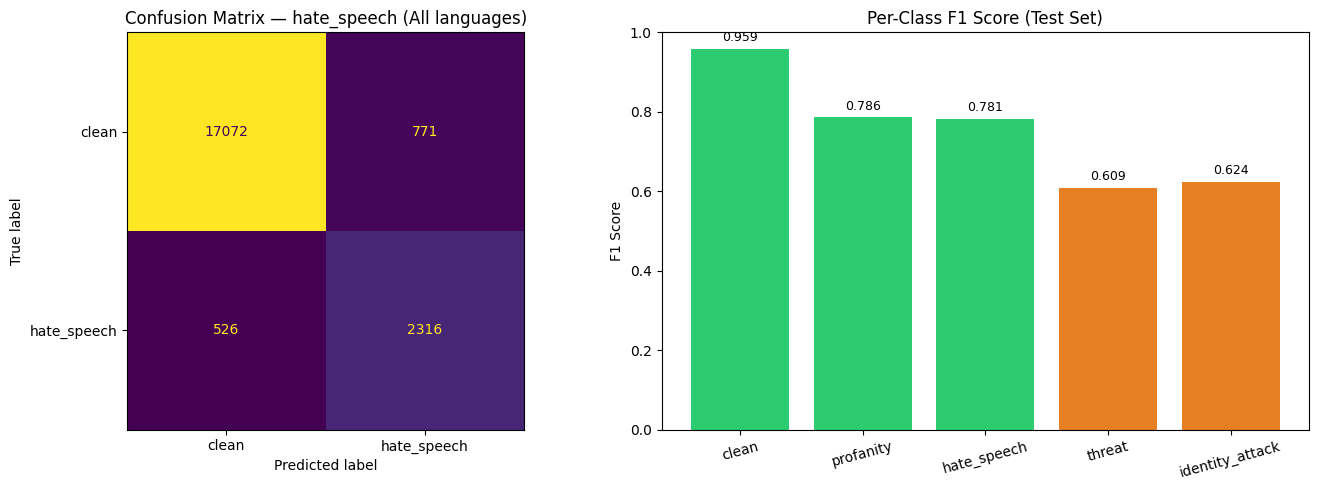

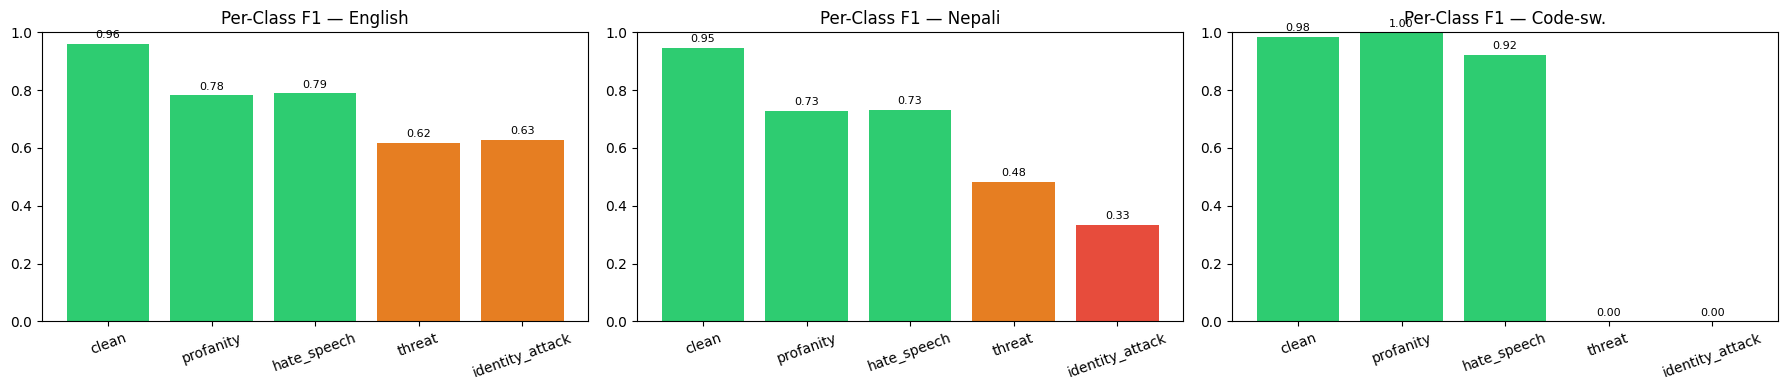

In [10]:
hs_idx  = LABELS.index("hate_speech")
hs_true = test_labels_arr[:, hs_idx].astype(int)
hs_pred = test_preds[:, hs_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(hs_true, hs_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["clean", "hate_speech"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — hate_speech (All languages)")

final_per_cls = f1_score(test_labels_arr, test_preds, average=None, zero_division=0)
colors = ["#2ecc71" if f > 0.7 else "#e67e22" if f > 0.4 else "#e74c3c" for f in final_per_cls]
axes[1].bar(LABELS, final_per_cls, color=colors)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Class F1 Score (Test Set)")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(final_per_cls):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "test_evaluation.png"), dpi=100, bbox_inches="tight")
plt.show()

# Per-language per-class F1 heatmap
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
for ax, (lang, lang_name) in zip(axes2, [("en","English"),("ne","Nepali"),("cs","Code-sw.")]):
    mask = test_langs_all == lang
    if mask.sum() == 0:
        ax.set_visible(False); continue
    per_cls = f1_score(test_labels_arr[mask], test_preds[mask], average=None, zero_division=0)
    colors2 = ["#2ecc71" if f > 0.7 else "#e67e22" if f > 0.4 else "#e74c3c" for f in per_cls]
    ax.bar(LABELS, per_cls, color=colors2)
    ax.set_ylim(0, 1); ax.set_title(f"Per-Class F1 — {lang_name}")
    ax.tick_params(axis="x", rotation=20)
    for i, v in enumerate(per_cls):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "per_language_f1.png"), dpi=100, bbox_inches="tight")
plt.show()


## Export Final Model


In [11]:
FINAL_DIR = os.path.join(WORK_DIR, "distilbert-hatespeech-final")
os.makedirs(FINAL_DIR, exist_ok=True)
best_model.save_pretrained(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)

with open(os.path.join(FINAL_DIR, "label_map.json"), "w") as f:
    json.dump({i: lbl for i, lbl in enumerate(LABELS)}, f, indent=2)

with open(os.path.join(FINAL_DIR, "thresholds.json"), "w") as f:
    json.dump(THRESHOLDS, f, indent=2)

print(f"Model successfully saved to {FINAL_DIR}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model successfully saved to /kaggle/working/distilbert-hatespeech-final
